Name: Priyanshi Mehta

Internship: Celebal Technologies - Data Science

Submission Date: 21 June 2026

Dataset: CIFAR-10 (60,000 color images, 32x32x3, 10 classes)

Assignment: Week 4 — Image Classification using ANN vs CNN, Data Augmentation, Training Strategies (Dropout, Batch Normalization, EarlyStopping)

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load DatasetWe use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.- 50,000 training images- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4674s 27us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

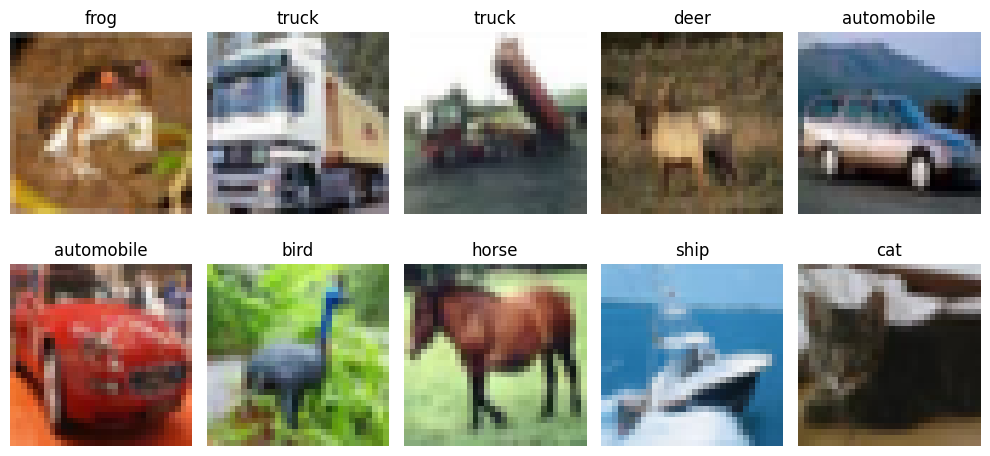

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 PreprocessingWe normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN ModelANN treats images as **flat vectors**, so it cannot preserve spatial features.This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2668 - loss: 2.0020 - val_accuracy: 0.3044 - val_loss: 1.8678
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3072 - loss: 1.8838 - val_accuracy: 0.3444 - val_loss: 1.8293
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3280 - loss: 1.8312 - val_accuracy: 0.3780 - val_loss: 1.7593
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3414 - loss: 1.7993 - val_accuracy: 0.3950 - val_loss: 1.7268
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3571 - loss: 1.7633 - val_accuracy: 0.3904 - val_loss: 1.7302
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3617 - loss: 1.7500 - val_accuracy: 0.4014 - val_loss: 1.7000
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3678 - loss: 1.7312 - val_accuracy: 0.4148 - val_loss: 1.6804
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3762 - loss: 1.7152 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4413 - loss: 1.6211
ANN Test Accuracy: 0.44130000472068787


# 🔹 Part 2: CNN ModelCNN preserves **spatial relationships** using:- Convolution layers- Pooling- Feature extraction- Hierarchical learningThis is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4540 - loss: 1.5318 - val_accuracy: 0.5062 - val_loss: 1.4364
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6031 - loss: 1.1424 - val_accuracy: 0.5928 - val_loss: 1.1690
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6636 - loss: 0.9672 - val_accuracy: 0.6158 - val_loss: 1.1631
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7068 - loss: 0.8401 - val_accuracy: 0.5274 - val_loss: 1.6397
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7389 - loss: 0.7424 - val_accuracy: 0.6986 - val_loss: 0.8906
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7649 - loss: 0.6657 - val_accuracy: 0.7026 - val_loss: 0.8640
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7913 - loss: 0.5960 - val_accuracy: 0.7256 - val_loss: 0.8575
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8082 - loss: 0.5447 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7165 - loss: 0.9665
CNN Test Accuracy: 0.7164999842643738


## 📈 Compare Learning Curves

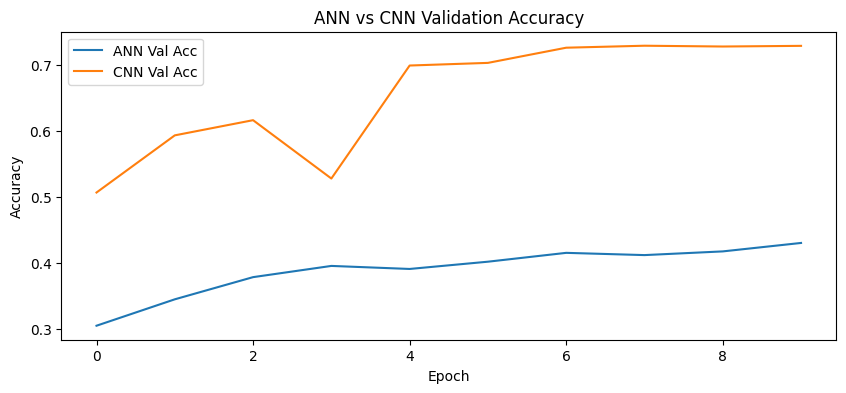

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images on the fly during training (random flips, rotations, and zooms). The model never sees the exact same image twice, which reduces overfitting and helps it **generalize better to unseen test data**.

Below we build the augmented CNN **and actually train + evaluate it**, so we can compare it against the plain CNN.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ▶️ Train the Augmented CNNThis actually runs the training (the original notebook left this commented out). We train for 10 epochs to match the ANN and CNN runs, so the comparison is fair.

In [11]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3618 - loss: 1.7446 - val_accuracy: 0.4754 - val_loss: 1.4212
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4626 - loss: 1.4954 - val_accuracy: 0.5546 - val_loss: 1.2427
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4989 - loss: 1.3945 - val_accuracy: 0.5614 - val_loss: 1.2241
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5245 - loss: 1.3294 - val_accuracy: 0.5876 - val_loss: 1.1464
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5432 - loss: 1.2814 - val_accuracy: 0.6028 - val_loss: 1.0943
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5578 - loss: 1.2478 - val_accuracy: 0.6342 - val_loss: 1.0435
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5671 - loss: 1.2244 - val_accuracy: 0.6282 - val_loss: 1.0543
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5765 - loss: 1.1980 - val_accuracy: 0

In [12]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6416 - loss: 1.0061
Augmented CNN Test Accuracy: 0.6416000127792358


## 📈 Updated Learning Curves: ANN vs CNN vs Augmented CNN

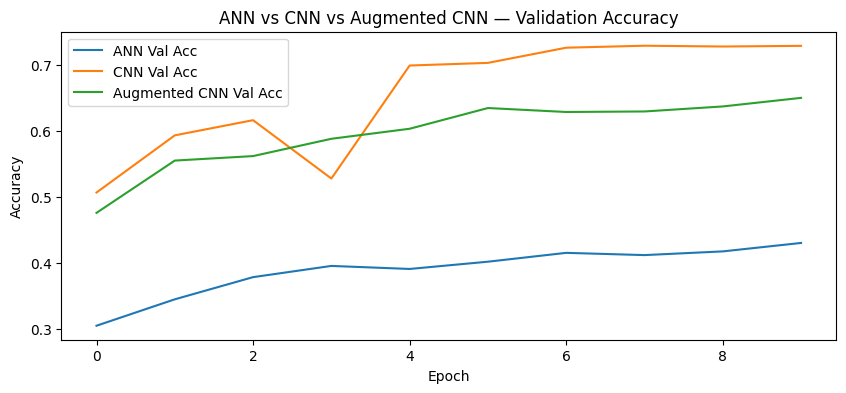

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN vs Augmented CNN — Validation Accuracy")
plt.legend()
plt.show()

# 📊 Final Comparison Table

In [14]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4413
1,CNN,0.7165
2,Augmented CNN,0.6416


# 🎓 Student Learning Tasks
Each task below is **fully implemented as runnable code**, not just described. Run each cell in order after running the sections above (they reuse `x_train_norm`, `x_train_flat`, `y_train`, etc. from earlier in the notebook).

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Task 1️⃣ — Increase ANN layers and observe performanceWe add more Dense layers (and a bit more depth/width) to the original ANN and compare validation accuracy against the baseline ANN.

In [15]:
# Task 1: Deeper ANN with more layers
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Baseline ANN Test Accuracy:", ann_test_acc)
print("Deeper ANN Test Accuracy:  ", deep_ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2501 - loss: 2.0223 - val_accuracy: 0.3360 - val_loss: 1.8539
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3051 - loss: 1.8894 - val_accuracy: 0.3334 - val_loss: 1.8381
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3279 - loss: 1.8351 - val_accuracy: 0.3686 - val_loss: 1.7770
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3451 - loss: 1.7949 - val_accuracy: 0.3780 - val_loss: 1.7297
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3527 - loss: 1.7722 - val_accuracy: 0.3624 - val_loss: 1.7620
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3659 - loss: 1.7455 - val_accuracy: 0.3798 - val_loss: 1.7387
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3729 - loss: 1.7270 - val_accuracy: 0.4034 - val_loss: 1.6782
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3766 - loss: 1.7130 - val_accuracy: 0.

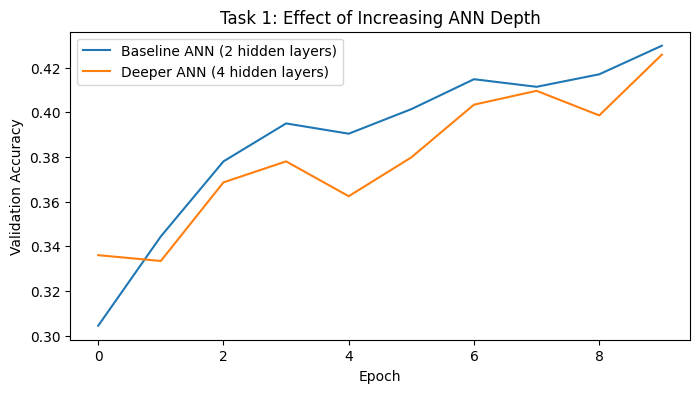

In [16]:
plt.figure(figsize=(8,4))
plt.plot(ann_history.history['val_accuracy'], label='Baseline ANN (2 hidden layers)')
plt.plot(deep_ann_history.history['val_accuracy'], label='Deeper ANN (4 hidden layers)')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Task 1: Effect of Increasing ANN Depth")
plt.legend()
plt.show()

**Observation:** Adding more Dense layers to an ANN usually gives only a small improvement (or can even slightly hurt accuracy / overfit faster), because the fundamental limitation isn't depth — it's that flattening the image destroys spatial structure. This reinforces why CNNs (which keep 2D structure) are the better architecture for images.

## Task 2️⃣ — Change CNN filters from 32 → 64 → 128The original CNN already uses 32 → 64 → 128 filters. Here we build a **wider variant** that scales each stage up further (64 → 128 → 256) to show the explicit effect of increasing filter counts.

In [17]:
# Task 2: CNN with scaled-up filter sizes (64 -> 128 -> 256)
wide_cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

wide_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

wide_cnn_history = wide_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

wide_cnn_test_loss, wide_cnn_test_acc = wide_cnn_model.evaluate(x_test_norm, y_test)
print("Original CNN (32-64-128) Test Accuracy:", cnn_test_acc)
print("Wider CNN (64-128-256) Test Accuracy:   ", wide_cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4433 - loss: 1.5545 - val_accuracy: 0.5192 - val_loss: 1.3056
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6060 - loss: 1.1318 - val_accuracy: 0.6038 - val_loss: 1.1839
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6769 - loss: 0.9422 - val_accuracy: 0.6732 - val_loss: 0.9441
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7225 - loss: 0.7989 - val_accuracy: 0.7024 - val_loss: 0.8712
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7606 - loss: 0.6851 - val_accuracy: 0.7088 - val_loss: 0.8406
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7918 - loss: 0.5979 - val_accuracy: 0.7178 - val_loss: 0.8733
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8199 - loss: 0.5156 - val_accuracy: 0.6736 - val_loss: 1.1902
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8440 - loss: 0.4425 - val_accuracy: 

**Observation:** More filters per layer let the CNN learn a richer set of features at each stage, which can improve accuracy — but it also increases parameters, training time, and overfitting risk. There's a trade-off between capacity and generalization.

## Task 3️⃣ — Increase epochs to 20We retrain the original CNN architecture for **20 epochs** instead of 10, to see whether accuracy keeps improving or starts to plateau/overfit.

In [18]:
# Task 3: Same CNN architecture, trained for 20 epochs
cnn_20ep_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_20ep_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_20ep_model.evaluate(x_test_norm, y_test)
print("CNN (10 epochs) Test Accuracy:", cnn_test_acc)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4742 - loss: 1.4812 - val_accuracy: 0.4872 - val_loss: 1.3945
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6132 - loss: 1.1077 - val_accuracy: 0.5740 - val_loss: 1.1610
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6694 - loss: 0.9441 - val_accuracy: 0.6474 - val_loss: 0.9847
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7095 - loss: 0.8360 - val_accuracy: 0.6822 - val_loss: 0.9023
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7378 - loss: 0.7437 - val_accuracy: 0.6862 - val_loss: 0.9145
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7668 - loss: 0.6622 - val_accuracy: 0.6432 - val_loss: 1.1398
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7874 - loss: 0.5972 - val_accuracy: 0.6716 - val_loss: 1.0059
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8076 - loss: 0.5398 - val_accuracy: 

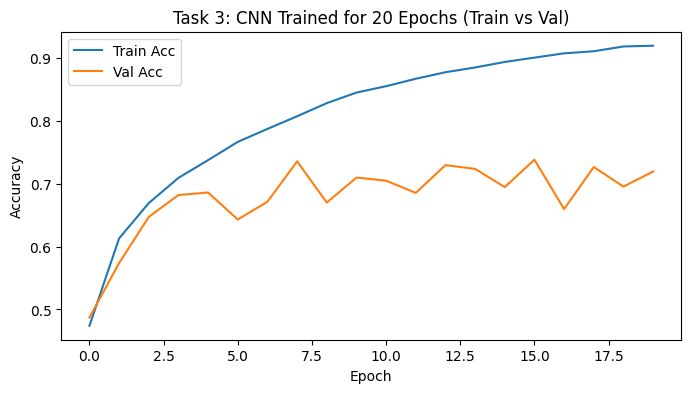

In [19]:
plt.figure(figsize=(8,4))
plt.plot(cnn_20ep_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 3: CNN Trained for 20 Epochs (Train vs Val)")
plt.legend()
plt.show()

**Observation:** Watch the gap between train and validation accuracy in the chart above. If train accuracy keeps rising while validation accuracy flattens or drops, that's a sign of **overfitting** — which motivates Task 4 (EarlyStopping).

## Task 4️⃣ — Add EarlyStopping`EarlyStopping` monitors validation loss and stops training automatically once the model stops improving, restoring the best weights. This prevents wasted epochs and overfitting.

In [20]:
# Task 4: Same CNN architecture, trained with EarlyStopping (up to 20 epochs)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_es_model.evaluate(x_test_norm, y_test)
print("Stopped after", len(cnn_es_history.history['loss']), "epochs (out of 20 max)")
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4670 - loss: 1.4959 - val_accuracy: 0.5976 - val_loss: 1.1454
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6023 - loss: 1.1376 - val_accuracy: 0.5324 - val_loss: 1.3832
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6625 - loss: 0.9663 - val_accuracy: 0.6538 - val_loss: 1.0263
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7003 - loss: 0.8554 - val_accuracy: 0.6566 - val_loss: 0.9780
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7336 - loss: 0.7586 - val_accuracy: 0.6522 - val_loss: 1.0648
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7612 - loss: 0.6781 - val_accuracy: 0.6996 - val_loss: 0.8897
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7841 - loss: 0.6158 - val_accuracy: 0.6878 - val_loss: 0.9572
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8030 - loss: 0.5533 - val_accuracy: 

**Observation:** `EarlyStopping` should stop training before all 20 epochs complete (check the printed epoch count above), and `restore_best_weights=True` ensures we keep the weights from the best validation-loss epoch rather than the final, possibly-overfit one.

## Task 5️⃣ — Add data augmentation trainingThis was already done earlier in the notebook (the **"🚀 Training Strategy Upgrade: Data Augmentation"** section above), where `aug_cnn_model` is trained for 10 epochs and evaluated as `aug_test_acc`. For completeness, we summarize that result here alongside all other student-task models.

In [21]:
# Task 5: Data augmentation result (trained earlier in the notebook)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Augmented CNN Test Accuracy: 0.6416000127792358


## 📊 Student Tasks — Combined Results

In [22]:
tasks_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "ANN (deeper, Task 1)",
        "CNN (baseline, 32-64-128)",
        "CNN (wider filters 64-128-256, Task 2)",
        "CNN (20 epochs, Task 3)",
        "CNN (EarlyStopping, Task 4)",
        "CNN (Data Augmentation, Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        deep_ann_test_acc,
        cnn_test_acc,
        wide_cnn_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ]
})
tasks_comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

,Model,Test Accuracy
0,"CNN (wider filters 64-128-256, Task 2)",0.7306
1,"CNN (baseline, 32-64-128)",0.7165
2,"CNN (20 epochs, Task 3)",0.7076
3,"CNN (EarlyStopping, Task 4)",0.6861
4,"CNN (Data Augmentation, Task 5)",0.6416
5,ANN (baseline),0.4413
6,"ANN (deeper, Task 1)",0.4333


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- Going **deeper in an ANN** gives limited gains, because flattening pixels throws away spatial information
- **Wider CNN filters** increase capacity and can boost accuracy, at the cost of more parameters and training time
- **More epochs** can help, but only up to a point — after that, the train/validation gap widens (overfitting)
- **EarlyStopping** automatically finds a good stopping point and avoids wasting time training past it
- **Data augmentation** improves generalization to unseen test images by exposing the model to varied versions of the training data
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**